In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from classlist import Linear, BatchNorm1d, Tanh

In [3]:
words = open("names.txt", "r").read().splitlines()
chars = sorted(list(set("".join(words))))
stoi = {".": 0}
stoi.update({s: i + 1 for i, s in enumerate(chars)})
itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)

block_size = 3
X = []
Y = []
for w in words:
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

N = len(X)
X = torch.tensor(X)
Y = torch.tensor(Y)

train_size = 0.8
dev_size = 0.1
test_size = 0.1
indices = torch.randperm(N)
n1 = int(N * train_size)
n2 = int(N * (train_size + dev_size))
X_train = X[indices[:n1]]
Y_train = Y[indices[:n1]]
X_dev = X[indices[n1:n2]]
Y_dev = Y[indices[n1:n2]]
X_test = X[indices[n2:]]
Y_test = Y[indices[n2:]]
N

228146

In [ ]:
n_emb = 10
n_hidden = 700
g = torch.Generator().manual_seed(42)
C = torch.randn((vocab_size, n_emb), generator=g)
layers = [
    Linear(n_emb * block_size, n_hidden, bias=False, nonlinearity="tanh", generator=g),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size, nonlinearity="linear", generator=g),
]
with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True

print(f"total parameters:{sum(p.nelement() for p in parameters)}")
batch_size = 128
iters = 10000
alpha = 0.3
alpha_decay_start = int(0.8 * iters)
alpha_decayed = alpha / 10

g = torch.Generator().manual_seed(42)

lossi = []
for i in range(iters):
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    cur_alpha = alpha if i < alpha_decay_start else alpha_decayed
    with torch.no_grad():
        for p in parameters:
            p -= cur_alpha * p.grad

    lossi.append(loss.item())

total parameters:41597


2.145632266998291

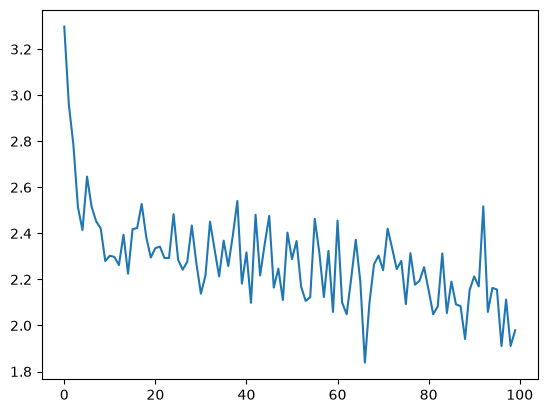

In [ ]:
plotloss = lossi[::100]
plt.plot(plotloss)
# plt.yscale('log')
lossi[-1]